T2: Artifact-Aware Context CNN + Transformer + SupCon
Device       : cuda
D_MODEL      : 128  N_HEADS: 8  Layers: 3  Dropout: 0.4
Context      : ±7  Window: 15
Loss         : Artifact-Weighted CE + SupCon (lambda=0.2, temp=0.05)
Projection   : 64
Seeds        : [42, 123, 256, 789, 999]

DATA_PATH    : D:\22\AA\preprocess\preprocessed_FFinal
SPLIT_PATH   : D:\22\AA\AA journal\preprocess\preprocessed_split_v2
EVAL_PATH    : D:\22\AA\AA journal\evaluation\context_cnn_transformer_c7_supcon_valfixed

Loading fixed subject split...
Split loaded -> Train:65  Val:11  Test:20
Train subjects : ['sub-001', 'sub-002', 'sub-004', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-016', 'sub-020', 'sub-022', 'sub-024', 'sub-025', 'sub-027', 'sub-029', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-039', 'sub-041', 'sub-043', 'sub-044', 'sub-046', 'sub-047', 'sub-048', 'sub-050', 'sub-054', 'sub-056', 'sub-059', 'sub-060', 'sub-062', 'sub-063', 'sub-066', 'sub-067', 'sub-070', 'sub-071', '

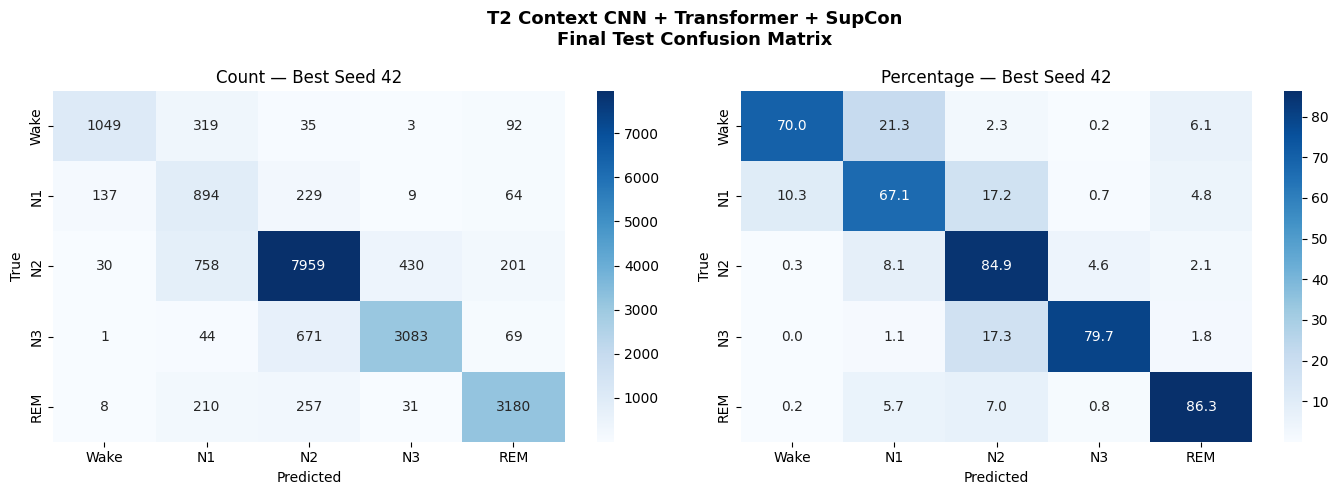

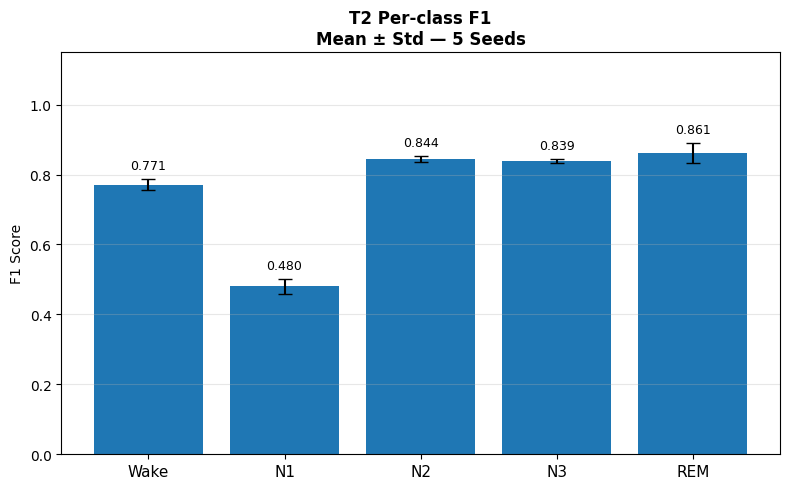

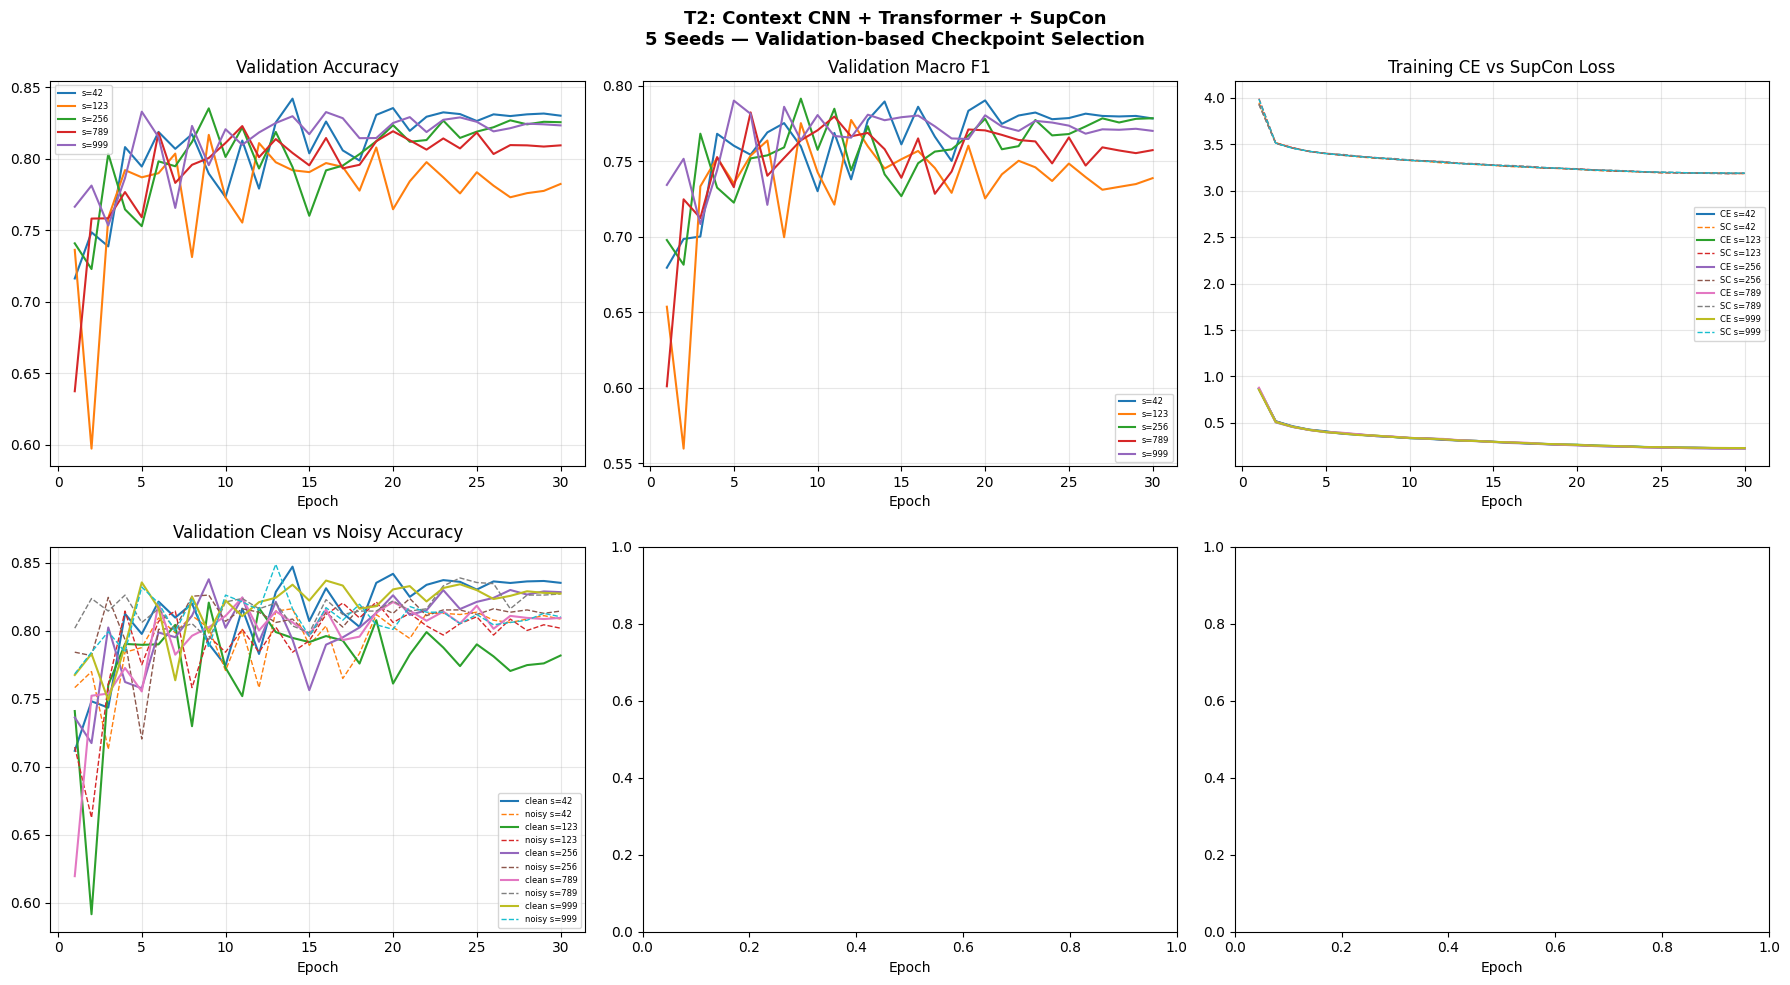


T2 TRAINING COMPLETE
Mean Test Accuracy : 80.62 ± 0.79%
Mean Test Macro F1 : 0.7590 ± 0.0075
Mean Test Kappa    : 0.7264 ± 0.0125
Mean Test N1 F1    : 0.4802 ± 0.0220

All outputs saved to:
D:\22\AA\AA journal\evaluation\context_cnn_transformer_c7_supcon_valfixed


In [1]:
# ============================================================
# T2: Artifact-Aware Context CNN + Transformer + SupCon
# Fixed Subject-Independent Train / Validation / Test Split
#
# Epoch CNN -> Intra-Epoch Transformer -> Inter-Epoch Transformer
#   -> Center Epoch Feature -> Classifier / Projection Head (SupCon)
#
# Loss = Artifact-Weighted CE + lambda * SupCon
# Context = 7 -> Window = 15
# Seeds = 42, 123, 256, 789, 999
# ============================================================

import os
import csv
import math
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


# ============================================================
# PATHS & CONFIG
# ============================================================

DATA_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
SPLIT_PATH = r"D:\22\AA\AA journal\preprocess\preprocessed_split_v2"
EVAL_PATH = r"D:\22\AA\AA journal\evaluation\context_cnn_transformer_c7_supcon_valfixed"
ARTIFACT_PATH = (
    r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0"
    r"\derivatives\eegfloss-v1.0"
)

os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]

CONTEXT = 7
WINDOW = 2 * CONTEXT + 1        # 15
N_EPOCHS = 30
BATCH_SIZE = 64
SEEDS = [42, 123, 256, 789, 999]

D_MODEL = 128
N_HEADS = 8
NUM_LAYERS = 3
DIM_FF = 256
DROPOUT = 0.4

SUPCON_LAMBDA = 0.2
SUPCON_TEMP = 0.05
PROJ_DIM = 64

ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("T2: Artifact-Aware Context CNN + Transformer + SupCon")
print("=" * 70)
print(f"Device       : {device}")
print(f"D_MODEL      : {D_MODEL}  N_HEADS: {N_HEADS}  Layers: {NUM_LAYERS}  Dropout: {DROPOUT}")
print(f"Context      : ±{CONTEXT}  Window: {WINDOW}")
print(f"Loss         : Artifact-Weighted CE + SupCon (lambda={SUPCON_LAMBDA}, temp={SUPCON_TEMP})")
print(f"Projection   : {PROJ_DIM}")
print(f"Seeds        : {SEEDS}")
print(f"\nDATA_PATH    : {DATA_PATH}")
print(f"SPLIT_PATH   : {SPLIT_PATH}")
print(f"EVAL_PATH    : {EVAL_PATH}")
print("=" * 70)


# ============================================================
# FIXED TRAIN / VAL / TEST SPLIT
# ============================================================

print("\nLoading fixed subject split...")

_paths = {
    "train": os.path.join(SPLIT_PATH, "_train_subs.npy"),
    "val": os.path.join(SPLIT_PATH, "_val_subs.npy"),
    "test": os.path.join(SPLIT_PATH, "_test_subs.npy"),
}

for name, p in _paths.items():
    if not os.path.exists(p):
        raise FileNotFoundError(f"\n{os.path.basename(p)} not found at:\n{SPLIT_PATH}\n\nPlease check SPLIT_PATH.")

TRAIN_SUBS = np.load(_paths["train"], allow_pickle=True).tolist()
VAL_SUBS = np.load(_paths["val"], allow_pickle=True).tolist()
TEST_SUBS = np.load(_paths["test"], allow_pickle=True).tolist()

assert set(TRAIN_SUBS).isdisjoint(VAL_SUBS), "ERROR: TRAIN/VAL subject overlap!"
assert set(TRAIN_SUBS).isdisjoint(TEST_SUBS), "ERROR: TRAIN/TEST subject overlap!"
assert set(VAL_SUBS).isdisjoint(TEST_SUBS), "ERROR: VAL/TEST subject overlap!"

print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Val:{len(VAL_SUBS)}  Test:{len(TEST_SUBS)}")
print(f"Train subjects : {TRAIN_SUBS}")
print(f"Val subjects   : {VAL_SUBS}")
print(f"Test subjects  : {TEST_SUBS}")


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================

def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg", f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None

    try:
        df = pd.read_csv(tsv_path, sep="\t")
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df["worst_score"] = df[available].max(axis=1).astype(int)
    df["sleep_epoch"] = ((df["offset"] - 1e-6) // epoch_duration).astype(int)

    epoch_scores = df.groupby("sleep_epoch")["worst_score"].max()
    n_ep = int(epoch_scores.index.max()) + 1
    weights = np.ones(n_ep, dtype=np.float32)

    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)

    return weights


# ============================================================
# DATASET
# ============================================================

class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path, artifact_path, context=CONTEXT):
        self.context = context
        self.data = []
        self.index = []

        label_counter = Counter()
        weight_counter = Counter()
        no_tsv_count = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                print(f"WARNING: Missing file: {fp}")
                continue

            with np.load(fp) as d:
                eeg = d["eeg"][:, [0, 1], :]          # F3:A2, C3:A2
                eog = d["eog"][:, [0], :]              # EOG1
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d["labels"].copy()

            n = len(labels)

            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            elif len(art_w) >= n:
                art_w = art_w[:n]
            else:
                pad = np.ones(n - len(art_w), dtype=np.float32)
                art_w = np.concatenate([art_w, pad])

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)] += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )

        total = len(self.index)
        ram = sum(s.nbytes for s, _ in self.data) / 1e9

        print(f"  Subjects : {len(self.data)}")
        print(f"  Samples  : {total:,}")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects (weight=1.0 default)")

        print("  Label counts:")
        for i, name in enumerate(LABEL_NAMES):
            print(f"    {name:6s}: {int(self.label_counts[i]):,}")

        print("  Artifact weight distribution:")
        if total > 0:
            for w in sorted(weight_counter.keys(), reverse=True):
                pct = weight_counter[w] / total * 100
                print(f"    w={w:.1f} : {weight_counter[w]:>8,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)   # WINDOW x CHANNEL x TIME (15 x 3 x 3000)
        y = int(labels[center_i])

        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32),
        )


print("\n" + "=" * 70)
print("BUILDING TRAIN DATASET")
print("=" * 70)
train_ds = ArtifactAwareDataset(TRAIN_SUBS, DATA_PATH, ARTIFACT_PATH)

print("\n" + "=" * 70)
print("BUILDING VALIDATION DATASET")
print("=" * 70)
val_ds = ArtifactAwareDataset(VAL_SUBS, DATA_PATH, ARTIFACT_PATH)

print("\n" + "=" * 70)
print("BUILDING TEST DATASET")
print("=" * 70)
test_ds = ArtifactAwareDataset(TEST_SUBS, DATA_PATH, ARTIFACT_PATH)

print("\nDatasets ready.")


# ============================================================
# POSITIONAL ENCODING
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# T2 MODEL — Artifact-Aware Context CNN + Transformer + SupCon
# ============================================================

class ContextCNNTransformerSupCon(nn.Module):
    def __init__(self, in_ch=3, d_model=D_MODEL, nhead=N_HEADS, num_layers=NUM_LAYERS,
                 dim_ff=DIM_FF, dropout=DROPOUT, n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM):
        super().__init__()
        self.context = context
        self.d_model = d_model

        # Epoch-level CNN
        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(), nn.MaxPool1d(4, 4),

            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),

            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(), nn.MaxPool1d(2, 2),

            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            intra_seq = self.epoch_cnn(dummy).shape[2]
        print(f"\nCNN intra-sequence length: {intra_seq}")

        # Intra-epoch transformer
        self.intra_pos = PositionalEncoding(d_model, max_len=intra_seq + 10, dropout=dropout)
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=dim_ff, dropout=dropout,
                activation="gelu", batch_first=True, norm_first=True,
            ),
            num_layers=1,
        )

        # Inter-epoch transformer
        self.inter_pos = PositionalEncoding(d_model, max_len=WINDOW + 2, dropout=dropout)
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=dim_ff, dropout=dropout,
                activation="gelu", batch_first=True, norm_first=True,
            ),
            num_layers=num_layers,
        )

        # Heads
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

        self.projector = nn.Sequential(   # SupCon only, training time
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape

        feat = self.epoch_cnn(x.view(B * W, C, T))     # (B*W) x D x seq
        feat = feat.permute(0, 2, 1)                    # (B*W) x seq x D

        feat = self.intra_transformer(self.intra_pos(feat))
        feat = feat.mean(dim=1)                          # (B*W) x D
        feat = feat.view(B, W, self.d_model)             # B x W x D

        feat = self.inter_transformer(self.inter_pos(feat))
        center_feat = feat[:, self.context, :]

        logits = self.classifier(center_feat)
        proj = F.normalize(self.projector(center_feat), dim=1)

        return logits, proj


# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupConLoss(nn.Module):
    def __init__(self, temperature=SUPCON_TEMP, mask_n1_only=False):
        super().__init__()
        self.temperature = temperature
        self.mask_n1_only = mask_n1_only

    def forward(self, features, labels):
        B = features.shape[0]
        device = features.device

        sim = torch.matmul(features, features.T) / self.temperature
        sim = sim - sim.max(dim=1, keepdim=True)[0].detach()

        labels_row, labels_col = labels.unsqueeze(1), labels.unsqueeze(0)
        pos_mask = (labels_row == labels_col).float()

        self_mask = torch.eye(B, device=device)
        pos_mask = pos_mask - self_mask
        denom_mask = 1 - self_mask

        exp_sim = torch.exp(sim) * denom_mask
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

        n_pos = pos_mask.sum(dim=1)
        anchor_mask = (labels == 1).float() if self.mask_n1_only else (n_pos > 0).float()

        loss_per_sample = -(pos_mask * log_prob).sum(dim=1) / (n_pos + 1e-8)
        loss = (loss_per_sample * anchor_mask).sum() / (anchor_mask.sum() + 1e-8)

        return loss


supcon_criterion = SupConLoss(temperature=SUPCON_TEMP, mask_n1_only=False)


# ============================================================
# LOSSES
# ============================================================

def artifact_weighted_ce(logits, labels, weights, class_weights):
    ce_loss = nn.CrossEntropyLoss(weight=class_weights, reduction="none")(logits, labels)
    weighted = ce_loss * weights
    valid = weights > 0
    return weighted.mean() if valid.sum() == 0 else weighted[valid].mean()


def combined_loss(logits, proj, labels, weights, class_weights):
    l_ce = artifact_weighted_ce(logits, labels, weights, class_weights)
    l_supcon = supcon_criterion(proj, labels)
    total = l_ce + SUPCON_LAMBDA * l_supcon
    return total, l_ce.item(), l_supcon.item()


# ============================================================
# CLASS WEIGHTS (train only)
# ============================================================

cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw = torch.FloatTensor(cw_np).to(device)

print("\n" + "=" * 70)
print("CLASS WEIGHTS — TRAIN ONLY")
print("=" * 70)
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"{name:6s}: {w:.4f}")


# ============================================================
# UTILITIES
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_loaders(seed):
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=torch.Generator().manual_seed(seed),
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader, test_loader


def train_epoch_fn(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_ce = total_sc = 0.0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device, non_blocking=True), y.to(device, non_blocking=True), w.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits, proj = model(x)
        loss, l_ce, l_sc = combined_loss(logits, proj, y, w, cw)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_ce += l_ce
        total_sc += l_sc

        preds.extend(logits.argmax(1).detach().cpu().numpy())
        labs.extend(y.detach().cpu().numpy())

        if (i + 1) % 300 == 0:
            print(f"  batch {i + 1}/{len(loader)}", end="\r")

    n = len(loader)
    acc = accuracy_score(labs, preds)
    f1 = f1_score(labs, preds, average="macro", zero_division=0)

    return total_loss / n, total_ce / n, total_sc / n, acc, f1


def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            logits, _ = model(x.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds, labs, weights_all = np.array(preds), np.array(labs), np.array(weights_all)

    acc = accuracy_score(labs, preds)
    f1 = f1_score(labs, preds, average="macro", zero_division=0)
    kappa = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)

    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)

    clean_acc = accuracy_score(labs[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else 0.0
    noisy_acc = accuracy_score(labs[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs, clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV SETUP
# ============================================================

csv_epoch_path = os.path.join(EVAL_PATH, "epoch_log.csv")
csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")

with open(csv_epoch_path, "w", newline="") as f:
    csv.writer(f).writerow([
        "seed", "epoch",
        "tr_loss", "tr_ce", "tr_supcon", "tr_acc", "tr_f1",
        "val_acc", "val_f1", "val_kappa", "val_clean_acc", "val_noisy_acc",
    ])

SUMMARY_FIELDS = [
    "seed", "acc", "f1_macro", "kappa",
    "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
    "clean_acc", "noisy_acc",
]

with open(csv_summary_path, "w", newline="") as f:
    csv.DictWriter(f, SUMMARY_FIELDS).writeheader()


# ============================================================
# TRAINING LOOP (5 seeds)
# ============================================================

all_seed_results = []

for seed_idx, seed in enumerate(SEEDS):
    print("\n" + "=" * 70)
    print(f"SEED {seed} ({seed_idx + 1}/{len(SEEDS)})")
    print("=" * 70)

    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(seed)

    print(f"Train batches : {len(train_loader)}")
    print(f"Val batches   : {len(val_loader)}")
    print(f"Test batches  : {len(test_loader)}")

    model = ContextCNNTransformerSupCon(
        in_ch=3, d_model=D_MODEL, nhead=N_HEADS, num_layers=NUM_LAYERS,
        dim_ff=DIM_FF, dropout=DROPOUT, n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM,
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters      : {n_params:,}")
    print(f"Trainable       : {trainable_params:,}")

    optimizer = optim.AdamW(
        model.parameters(), lr=5e-4, weight_decay=3e-4, betas=(0.9, 0.98), eps=1e-9
    )

    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step, warmup_steps=warmup_steps, total_steps=total_steps):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    best_val_f1, best_val_acc, best_epoch = -1.0, -1.0, 0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_ce, tr_sc, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler
        )

        # Validation only — test is untouched here
        (vl_acc, vl_f1, vl_kap, vl_per, _, _, vl_clean_acc, vl_noisy_acc,
         vl_n_clean, vl_n_noisy) = evaluate_fn(model, val_loader)

        saved = ""
        if vl_f1 > best_val_f1:
            best_val_f1, best_val_acc, best_epoch = vl_f1, vl_acc, epoch
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST VAL"

        lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "tr_loss": tr_loss, "tr_ce": tr_ce, "tr_sc": tr_sc,
            "tr_acc": tr_acc, "tr_f1": tr_f1,
            "vl_acc": vl_acc, "vl_f1": vl_f1, "vl_kap": vl_kap,
            "vl_clean_acc": vl_clean_acc, "vl_noisy_acc": vl_noisy_acc,
        })

        print(
            f"Ep[{epoch:02d}/{N_EPOCHS}] Loss:{tr_loss:.3f} (CE:{tr_ce:.3f}+SC:{tr_sc:.3f}) "
            f"TrAcc:{tr_acc:.3f} ValAcc:{vl_acc:.3f} ValF1:{vl_f1:.3f} k:{vl_kap:.3f} "
            f"LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Val Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Val Clean:{vl_clean_acc:.3f}({vl_n_clean})  Noisy:{vl_noisy_acc:.3f}({vl_n_noisy})")

        with open(csv_epoch_path, "a", newline="") as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_ce:.4f}", f"{tr_sc:.4f}", f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{vl_clean_acc:.4f}", f"{vl_noisy_acc:.4f}",
            ])

    # Load best validation checkpoint, run final test
    print(f"\nLoading BEST validation checkpoint (epoch={best_epoch}, ValF1={best_val_f1:.4f})")
    model.load_state_dict(torch.load(best_path, map_location=device))

    print("\nRunning FINAL TEST evaluation...")
    (fin_acc, fin_f1, fin_kap, fin_per, fin_preds, fin_labels, fin_clean_acc,
     fin_noisy_acc, fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    print("\n" + "=" * 70)
    print(f"SEED {seed} FINAL TEST RESULT")
    print("=" * 70)
    print(f"Best Val Epoch : {best_epoch}")
    print(f"Best Val F1    : {best_val_f1:.4f}")
    print(f"Test Accuracy  : {fin_acc * 100:.2f}%")
    print(f"Test Macro F1  : {fin_f1:.4f}")
    print(f"Test Kappa     : {fin_kap:.4f}")
    print(f"Test Clean Acc : {fin_clean_acc * 100:.2f}% ({fin_n_clean})")
    print(f"Test Noisy Acc : {fin_noisy_acc * 100:.2f}% ({fin_n_noisy})")
    print("\nPer-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        print(f"  {name:6s}: {fin_per[i]:.4f}")
    print("=" * 70)

    result = {
        "seed": seed, "acc": fin_acc, "f1": fin_f1, "kappa": fin_kap,
        "per_cls": fin_per, "clean_acc": fin_clean_acc, "noisy_acc": fin_noisy_acc,
        "n_clean": fin_n_clean, "n_noisy": fin_n_noisy,
        "preds": fin_preds, "labels": fin_labels,
        "history": history, "best_epoch": best_epoch, "best_val_f1": best_val_f1,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, "a", newline="") as f:
        csv.DictWriter(f, SUMMARY_FIELDS).writerow({
            "seed": seed,
            "acc": round(fin_acc, 4), "f1_macro": round(fin_f1, 4), "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2": round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4), "f1_REM": round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4), "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL 5-SEED REPORT
# ============================================================

print("\n" + "=" * 70)
print("T2 — 5-SEED FINAL TEST REPORT")
print("=" * 70)

accs = np.array([r["acc"] for r in all_seed_results]) * 100
f1s = np.array([r["f1"] for r in all_seed_results])
kappas = np.array([r["kappa"] for r in all_seed_results])
n1s = np.array([r["per_cls"][1] for r in all_seed_results])
clean_accs = np.array([r["clean_acc"] for r in all_seed_results]) * 100
noisy_accs = np.array([r["noisy_acc"] for r in all_seed_results]) * 100

print(f"\n{'Seed':<8}{'Acc%':>8}{'F1':>9}{'Kappa':>9}{'N1 F1':>9}")
print("-" * 50)
for r in all_seed_results:
    print(f"{r['seed']:<8}{r['acc'] * 100:>8.2f}{r['f1']:>9.4f}{r['kappa']:>9.4f}{r['per_cls'][1]:>9.4f}")
print("-" * 50)
print(f"{'Mean':<8}{accs.mean():>8.2f}{f1s.mean():>9.4f}{kappas.mean():>9.4f}{n1s.mean():>9.4f}")
print(f"{'Std':<8}{accs.std():>8.2f}{f1s.std():>9.4f}{kappas.std():>9.4f}{n1s.std():>9.4f}")

print("\nPaper format:")
print(f"Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"N1 F1    : {n1s.mean():.4f} ± {n1s.std():.4f}")

print("\nPer-class F1 (mean ± std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r["per_cls"][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} ± {vals.std():.4f}")

with open(csv_summary_path, "a", newline="") as f:
    writer = csv.DictWriter(f, SUMMARY_FIELDS)
    writer.writerow({
        "seed": "mean",
        "acc": round(accs.mean() / 100, 4), "f1_macro": round(f1s.mean(), 4), "kappa": round(kappas.mean(), 4),
        "f1_Wake": round(np.mean([r["per_cls"][0] for r in all_seed_results]), 4),
        "f1_N1": round(np.mean([r["per_cls"][1] for r in all_seed_results]), 4),
        "f1_N2": round(np.mean([r["per_cls"][2] for r in all_seed_results]), 4),
        "f1_N3": round(np.mean([r["per_cls"][3] for r in all_seed_results]), 4),
        "f1_REM": round(np.mean([r["per_cls"][4] for r in all_seed_results]), 4),
        "clean_acc": round(clean_accs.mean() / 100, 4), "noisy_acc": round(noisy_accs.mean() / 100, 4),
    })
    writer.writerow({
        "seed": "std",
        "acc": round(accs.std() / 100, 4), "f1_macro": round(f1s.std(), 4), "kappa": round(kappas.std(), 4),
        "f1_Wake": round(np.std([r["per_cls"][0] for r in all_seed_results]), 4),
        "f1_N1": round(np.std([r["per_cls"][1] for r in all_seed_results]), 4),
        "f1_N2": round(np.std([r["per_cls"][2] for r in all_seed_results]), 4),
        "f1_N3": round(np.std([r["per_cls"][3] for r in all_seed_results]), 4),
        "f1_REM": round(np.std([r["per_cls"][4] for r in all_seed_results]), 4),
        "clean_acc": round(clean_accs.std() / 100, 4), "noisy_acc": round(noisy_accs.std() / 100, 4),
    })

best_r = max(all_seed_results, key=lambda r: r["f1"])

print("\n" + "=" * 70)
print(f"BEST TEST SEED: {best_r['seed']}")
print(f"Best Test Accuracy : {best_r['acc'] * 100:.2f}%")
print(f"Best Test Macro F1 : {best_r['f1']:.4f}")
print(f"Best Test Kappa    : {best_r['kappa']:.4f}")
print("=" * 70)


# ============================================================
# CONFUSION MATRIX — BEST SEED
# ============================================================

cm = confusion_matrix(best_r["labels"], best_r["preds"])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap="Blues", ax=axes[0])
axes[0].set_title(f"Count — Best Seed {best_r['seed']}")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt=".1f", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap="Blues", ax=axes[1])
axes[1].set_title(f"Percentage — Best Seed {best_r['seed']}")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")

fig.suptitle("T2 Context CNN + Transformer + SupCon\nFinal Test Confusion Matrix",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=150)
plt.show()


# ============================================================
# PER-CLASS F1 PLOT
# ============================================================

per_means = np.array([[r["per_cls"][i] for r in all_seed_results] for i in range(5)]).mean(axis=1)
per_stds = np.array([[r["per_cls"][i] for r in all_seed_results] for i in range(5)]).std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(np.arange(5), per_means, yerr=per_stds, capsize=5)
ax.set_xticks(np.arange(5))
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.15)
ax.set_title("T2 Per-class F1\nMean ± Std — 5 Seeds", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

for bar, m, s in zip(bars, per_means, per_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.02,
            f"{m:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1_5seed.png"), dpi=150)
plt.show()


# ============================================================
# TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for r in all_seed_results:
    h = r["history"]
    eps = [x["epoch"] for x in h]

    axes[0][0].plot(eps, [x["vl_acc"] for x in h], lw=1.5, label=f"s={r['seed']}")
    axes[0][1].plot(eps, [x["vl_f1"] for x in h], lw=1.5, label=f"s={r['seed']}")

    axes[0][2].plot(eps, [x["tr_ce"] for x in h], lw=1.5, label=f"CE s={r['seed']}")
    axes[0][2].plot(eps, [x["tr_sc"] for x in h], lw=1.0, ls="--", label=f"SC s={r['seed']}")

    axes[1][0].plot(eps, [x["vl_clean_acc"] for x in h], lw=1.5, label=f"clean s={r['seed']}")
    axes[1][0].plot(eps, [x["vl_noisy_acc"] for x in h], lw=1.0, ls="--", label=f"noisy s={r['seed']}")

titles = [
    "Validation Accuracy", "Validation Macro F1", "Training CE vs SupCon Loss",
    "Validation Clean vs Noisy Accuracy", "", "",
]

for ax, title in zip(axes.flat, titles):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    if title:
        ax.legend(fontsize=6)
        ax.grid(alpha=0.3)

fig.suptitle("T2: Context CNN + Transformer + SupCon\n5 Seeds — Validation-based Checkpoint Selection",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves_5seeds.png"), dpi=150)
plt.show()


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("T2 TRAINING COMPLETE")
print("=" * 70)
print(f"Mean Test Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"Mean Test Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"Mean Test Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"Mean Test N1 F1    : {n1s.mean():.4f} ± {n1s.std():.4f}")
print(f"\nAll outputs saved to:")
print(EVAL_PATH)
print("=" * 70)